# Linear Field Probes (COLM-style Summary)

This notebook mirrors the original `stable-distribution/figure_LFP_COLM.ipynb` panel logic, adapted to this repo's probe paths.

Panels:
- **A — separability**: test accuracy vs layer
- **B — continuity**: cosine similarity matrix of class vectors
- **C — interpolation**: leave-one-out kernel-gram interpolation at `μ={350,450,550,650}`
- **D — transfer**: accuracy vs `Δμ` (original hard-coded points by default)


In [11]:
# imports
from pathlib import Path
import re
import numpy as np
import torch
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

try:
    import seaborn as sns
except ModuleNotFoundError:
    sns = None
    print('seaborn not installed; using matplotlib heatmap fallback')

print('imports ok')


imports ok


In [12]:
# helpers
def parse_mean(name: str) -> float:
    """Parse mean from labels like gaussian_m300_s100_l1000_n10 (or mu_300)."""
    for pat in (r"mu[_=]?(\d+)", r"m(\d+)"):
        m = re.search(pat, name)
        if m:
            return float(m.group(1))
    digits = re.findall(r"\d+", name)
    if digits:
        return float(digits[0])
    raise ValueError(f"Cannot parse mean from '{name}'")

@torch.no_grad()
def normalize_rows(W: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    return W / W.norm(dim=1, keepdim=True).clamp_min(eps)

@torch.no_grad()
def interpolate_kernel_gram(
    W: torch.Tensor,
    mu_vals: torch.Tensor,
    mu_star: float,
    lam: float = 1e-3,
    eps: float = 1e-12,
) -> torch.Tensor:
    """Kernel-gram interpolation in normalized weight space.

    Assumes `mu_vals` are sorted ascending and `mu_star` is strictly between two entries.
    """
    Wn = normalize_rows(W, eps=eps)
    j = int(torch.searchsorted(mu_vals, torch.tensor(mu_star, device=mu_vals.device)).item())
    if j <= 0 or j >= mu_vals.numel():
        raise ValueError("mu_star must lie strictly between two values in mu_vals")
    i = j - 1
    mu_i, mu_j = float(mu_vals[i].item()), float(mu_vals[j].item())
    t = 0.0 if mu_j == mu_i else float((mu_star - mu_i) / (mu_j - mu_i))
    t = max(0.0, min(1.0, t))

    G = Wn @ Wn.T
    k_star = (1.0 - t) * G[i, :] + t * G[j, :]
    A = G + lam * torch.eye(G.size(0), device=G.device, dtype=G.dtype)
    alpha = torch.linalg.solve(A, k_star.to(dtype=A.dtype))
    w_hat = alpha @ Wn
    return w_hat / w_hat.norm().clamp_min(eps)

def infer_base_dir() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / 'probes').exists() and (cwd / 'data').exists():
        return cwd
    if (cwd.parent / 'probes').exists() and (cwd.parent / 'data').exists():
        return cwd.parent
    raise FileNotFoundError('Could not infer repo root containing probes/ and data/')

def find_probe_run(probe_root: Path, probe_run_name: str | None):
    if probe_run_name is not None:
        run = probe_root / probe_run_name
        if not run.exists():
            raise FileNotFoundError(f'Probe run not found: {run}')
        return run

    runs = []
    for p in probe_root.glob('epoch*_biasFalse'):
        if p.is_dir():
            m = re.search(r'epoch(\d+)_biasFalse', p.name)
            if m:
                runs.append((int(m.group(1)), p))
    if not runs:
        raise FileNotFoundError(f'No probe runs found under {probe_root}')
    runs.sort(key=lambda x: x[0])
    return runs[-1][1]  # latest epoch by default


In [13]:
# config
BASE_DIR = infer_base_dir()
probe_path = BASE_DIR / 'probes' / 'epoch100_biasFalse'

# Layer used for panels B/C/D (same role as original notebook `layer` variable)
layer = 15

# figure size (COLM row layout)
width_cm = 5.5 * 2.54
height_cm = 1.8 * 2.54

# save figure?
save_figure = False
out_path = BASE_DIR / 'figures' / 'figure_LFP_COLM_adapted.pdf'

# Panel D: keep original transfer points by default
USE_HARDCODED_TRANSFER = True
delta_mu = [0, 50, 100, 150, 200]
accuracy = [0.8965, 0.5500, 0.5000, 0.5000, 0.5000]

print('BASE_DIR:', BASE_DIR)
print('probe_path:', probe_path)


BASE_DIR: /mnt/polished-lake/home/rsarfati/projects/shape-of-beliefs
probe_path: /mnt/polished-lake/home/rsarfati/projects/shape-of-beliefs/probes/epoch100_biasFalse


In [14]:
# Load data for all four panels
layer_files = sorted(
    probe_path.glob('linear_probe_layer*.pt'),
    key=lambda p: int(p.stem.split('layer')[-1])
)
if not layer_files:
    raise FileNotFoundError(f'No linear_probe_layer*.pt found in {probe_path}')

# Panel A: test accuracy vs layer
layers, test_accs = [], []
for fp in layer_files:
    data = torch.load(fp, map_location='cpu')
    layer_idx = int(data.get('layer', fp.stem.split('layer')[-1]))
    layers.append(layer_idx)
    test_accs.append(float(data['test_accuracy']))

# Pick layer file for B/C/D
layer_to_file = {int(torch.load(fp, map_location='cpu').get('layer', fp.stem.split('layer')[-1])): fp for fp in layer_files}
if layer not in layer_to_file:
    layer = max(layer_to_file.keys())
    print(f'Configured layer not found; using layer={layer}')

probe_layer = torch.load(layer_to_file[layer], map_location='cpu')

# Panel B: cosine matrix
cosine_similarity_matrix = probe_layer['cosine_matrix'].cpu().numpy()
number_of_mu = cosine_similarity_matrix.shape[0]
mu_labels = [rf"$\mu_{i}$" for i in range(1, number_of_mu + 1)]

# Panel C: interpolation (same targets as original)
w = probe_layer['probe_state_dict']['weight'].to(torch.float32)  # [num_mu, d_model]
labels = probe_layer['train_datasets']

mu_vals_full = torch.tensor([parse_mean(name) for name in labels], device=w.device, dtype=w.dtype)
mu_vals_full, sort_idx = torch.sort(mu_vals_full)
W_full = w[sort_idx]
Wn_full = normalize_rows(W_full)

mu_targets = [350.0, 450.0, 550.0, 650.0]
cos_sims = []
for mu_star in mu_targets:
    idx_true = (mu_vals_full == mu_star).nonzero(as_tuple=True)[0]
    if idx_true.numel() == 0:
        raise ValueError(f'mu={mu_star} not found in labels.')
    w_true = Wn_full[idx_true[0]]

    # leave mu_star out for interpolation
    mask = mu_vals_full != mu_star
    mu_interp = mu_vals_full[mask]
    W_interp = W_full[mask]

    # mu_star must remain bracketed
    if not ((mu_interp < mu_star).any() and (mu_interp > mu_star).any()):
        raise ValueError(f'mu={mu_star} is not bracketed by remaining mus.')

    w_hat = interpolate_kernel_gram(W_interp, mu_interp, mu_star, lam=1e-3, eps=1e-12)
    cos_sims.append(F.cosine_similarity(w_true, w_hat, dim=0).item())

# Panel D: transfer
if not USE_HARDCODED_TRANSFER:
    # Optional fallback from in-domain per_dataset accuracy grouped by |Δμ|
    per_dataset_acc = probe_layer.get('per_dataset_accuracy', {})
    delta_to_acc = {}
    for ds_name, acc in per_dataset_acc.items():
        dmu = abs(parse_mean(ds_name) - 500.0)
        delta_to_acc.setdefault(dmu, []).append(float(acc))
    delta_mu = sorted(delta_to_acc.keys())
    accuracy = [float(np.mean(delta_to_acc[d])) for d in delta_mu]

print('loaded layers:', layers)
print('plot layer:', layer)
print('mu targets:', mu_targets)


loaded layers: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
plot layer: 15
mu targets: [350.0, 450.0, 550.0, 650.0]


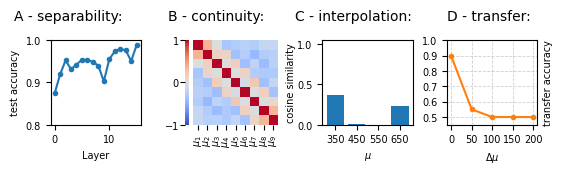

In [15]:
# Figure
cm = 1 / 2.54
fig, axes = plt.subplots(
    1, 4,
    figsize=(width_cm * cm, height_cm * cm),
    gridspec_kw={'wspace': 0.36, 'width_ratios': [1, 1.25, 1, 1]},
)
ax_acc, ax_cos, ax_bl, ax_br = axes

# Keep all artists inside the fixed canvas
fig.subplots_adjust(left=0.08, right=0.965, bottom=0.33, top=0.80)

# Panel A: test accuracy vs layer
ax_acc.plot(layers, test_accs, marker='.')
ax_acc.set_xlabel('Layer', fontsize=7)
ax_acc.set_ylabel('test accuracy', fontsize=7)
ax_acc.set_ylim(0.8, 1.0)
ax_acc.tick_params(labelsize=7)
ax_acc.set_yticks([0.8, 0.9, 1.0])
ax_acc.set_yticklabels(['0.8', '0.9', '1.0'], fontsize=7)

# Panel B: cosine similarity matrix
if sns is not None:
    ax_cos = sns.heatmap(
        cosine_similarity_matrix,
        ax=ax_cos,
        cmap='coolwarm',
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        cbar=False,
    )
    mappable = ax_cos.collections[0]
else:
    im = ax_cos.imshow(cosine_similarity_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='equal')
    mappable = im

ax_cos.set_anchor('N')
ax_cos.set_xticks([i + 0.5 for i in range(len(mu_labels))] if sns is not None else range(len(mu_labels)))
ax_cos.set_yticks([i + 0.5 for i in range(len(mu_labels))] if sns is not None else range(len(mu_labels)))
ax_cos.set_xticklabels(mu_labels, rotation=90, fontsize=7)
for tick in ax_cos.get_xticklabels():
    tick.set_fontsize(7)
ax_cos.set_yticklabels(mu_labels, rotation=0, fontsize=7)
ax_cos.set_yticks([])
ax_cos.tick_params(labelsize=7)

# Left colorbar for panel B
divider = make_axes_locatable(ax_cos)
cax = divider.append_axes('left', size='5%', pad=0.04)
cb = fig.colorbar(mappable, cax=cax, orientation='vertical', ticks=[-1, 0, 1])
cb.ax.tick_params(labelsize=7, pad=1)
cb.outline.set_visible(False)
for spine in cax.spines.values():
    spine.set_visible(False)
cax.yaxis.set_ticks_position('left')

# Panel C: interpolation
ax_bl.bar(range(len(mu_targets)), cos_sims, color='tab:blue')
ax_bl.tick_params(labelsize=7)
ax_bl.set_xticks(range(len(mu_targets)))
ax_bl.set_xticklabels([f"{int(m)}" for m in mu_targets], fontsize=7)
ax_bl.set_xlabel(r'$\mu$', fontsize=7)
ax_bl.set_ylim(0, 1.05)
ax_bl.set_ylabel('cosine similarity', fontsize=7, labelpad=1)

# Panel D: transfer
ax_br.plot(delta_mu, accuracy, marker='.', linestyle='-', color='tab:orange')
ax_br.tick_params(labelsize=7)
ax_br.set_xticks(delta_mu)
ax_br.set_xlabel(r'$\Delta \mu$', fontsize=7)
ax_br.set_ylim(0.45, 1.0)
ax_br.set_yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
ax_br.set_ylabel('transfer accuracy', fontsize=7)
ax_br.yaxis.tick_left()
ax_br.yaxis.set_label_position('right')
ax_br.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)

# Panel titles
labels = ['A - separability:', 'B - continuity:', 'C - interpolation:', 'D - transfer:']
axes_for_labels = [ax_acc, ax_cos, ax_bl, ax_br]
x_offsets = [-0.4, -0.3, -0.3, 0.00]
for label, ax, x in zip(labels, axes_for_labels, x_offsets):
    ax.text(
        x, 1.2, label,
        transform=ax.transAxes,
        fontsize=10,
        fontweight='normal',
        va='bottom',
        ha='left',
    )

if save_figure:
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path)
    print(f'saved {out_path}')
plt.show()
